# Data Processing Algorithm for TRXRD

In [47]:
from pathlib import Path
import re
import numpy as np
import tifffile as tf
import matplotlib.pyplot as plt
from skimage import feature, filters, exposure
from skimage.morphology import binary_dilation, disk
from joblib import Parallel, delayed
import pyFAI

%matplotlib widget

## Loading File Information

In [9]:
FIGSIZE = (12, 4)

_FILENAME_PATTERN = re.compile(
    r"(?P<fluence>[-+]?\d*.?\d+)fs"
    r"hw(?P<delay>[-+]?\d*.?\d+(?:e[-+]?\d+)?)"
    r"delay(?P<image_number>\d+).tif$",
    re.IGNORECASE,
)

def _get_counts(data_array, plot=False):
    """
    Sum each image over axes (1, 2) and return counts per image.


    Parameters
    ----------
    data_array : np.ndarray
        3D array of shape (N, rows, cols).
    plot : bool, optional
        If True, plot counts versus image index.

    Returns
    -------
    np.ndarray
        1D array of counts for each image.
    """

    if len(data_array) == 0:
        raise ValueError("Input data_array is empty.")

    if data_array.ndim != 3:
        raise ValueError("Input data_array is not 3 dimensional.")

    counts = np.sum(data_array, axis=(1, 2))

    if plot:
        plt.figure(figsize=FIGSIZE)
        plt.plot(np.arange(len(counts)), counts)
        plt.xlabel("Image index")
        plt.ylabel("Counts")
        plt.title("Counts per image")
        plt.tight_layout()
        plt.show()

    return counts


def _parse_filename(file_name):
    """
    Parse one filename and extract fluence, delay, and image number.

    
    Parameters
    ----------
    file_name : str or Path

    Returns
    -------
    tuple
        (fluence, delay, image_number)
    """
    name = Path(file_name).name
    match = _FILENAME_PATTERN.search(name)

    if match is None:
        raise ValueError(f"Could not parse filename: {name}")

    fluence = float(match.group("fluence"))
    delay = float(match.group("delay"))
    image_number = int(match.group("image_number"))

    return fluence, delay, image_number



def get_image_details(file_names, sort=True, filter_data=False, plot=False):
    """
    Read TIFF images and extract filename metadata using regex.


    Parameters
    ----------
    file_names : list of str or Path
        TIFF file paths to read.
    sort : bool, optional
        If True, sort data by image_number.
    filter_data : bool or list, optional
        If False, use all data.
        If list-like [min_index, max_index], keep only that slice after sorting.
    plot : bool, optional
        If True, show diagnostic plots for the first image and counts.

    Returns
    -------
    data_array : np.ndarray
        3D array of shape (N, rows, cols).
    fluence : np.ndarray
        1D array of fluence values.
    delay : np.ndarray
        1D array of delay values.
    image_number : np.ndarray
        1D array of image numbers.
    counts : np.ndarray
        1D array of summed counts per image.
    """
    if len(file_names) == 0:
        raise ValueError("file_names is empty.")

    fluence = []
    delay = []
    image_number = []
    cleaned_files = []

    for file_name in file_names:
        f_val, d_val, i_val = _parse_filename(file_name)
        fluence.append(f_val)
        delay.append(d_val)
        image_number.append(i_val)
        cleaned_files.append(str(file_name))

    fluence = np.array(fluence, dtype=float)
    delay = np.array(delay, dtype=float)
    image_number = np.array(image_number, dtype=int)
    cleaned_files = np.array(cleaned_files, dtype=str)

    if sort:
        idx_sort = np.argsort(image_number)
        fluence = fluence[idx_sort]
        delay = delay[idx_sort]
        image_number = image_number[idx_sort]
        cleaned_files = cleaned_files[idx_sort]

    if isinstance(filter_data, (list, tuple, np.ndarray)):
        if len(filter_data) != 2:
            raise ValueError("filter_data must be False or [min_index, max_index].")

        min_val, max_val = filter_data

        if min_val < 0 or max_val > len(cleaned_files):
            raise ValueError("filter_data range is out of bounds.")

        cleaned_files = cleaned_files[min_val:max_val]
        fluence = fluence[min_val:max_val]
        delay = delay[min_val:max_val]
        image_number = image_number[min_val:max_val]

    data_array = tf.imread(list(cleaned_files))
    counts = _get_counts(data_array)

    if plot:
        test = data_array[0]

        plt.figure(figsize=FIGSIZE)

        plt.subplot(1, 3, 1)
        plt.imshow(test, cmap="jet")
        plt.xlabel("Pixel")
        plt.ylabel("Pixel")
        plt.title("Linear Scale")

        plt.subplot(1, 3, 2)
        plt.imshow(np.log(test + 1), cmap="jet")
        plt.xlabel("Pixel")
        plt.ylabel("Pixel")
        plt.title("Log Scale")

        plt.subplot(1, 3, 3)
        plt.hist(test.reshape(-1), bins=30, edgecolor="r", histtype="bar", alpha=0.5)
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Pixel Number")
        plt.title("Histogram")
        plt.yscale("log")

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=FIGSIZE)
        plt.plot(counts, "o-")
        plt.xlabel("Image Number")
        plt.ylabel("Counts")
        plt.title("Total Counts")
        plt.tight_layout()
        plt.show()

    data_dict = {"images": data_array, "fluence": fluence, "delay": delay, "image_number": image_number, "counts": counts}

    return data_dict



125 TIFF files found in C:\Users\lheald\Box\TRXRDPython\testdata\detimages.


C:\Users\lheald\AppData\Local\Temp\ipykernel_7124\2280024160.py:162: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(test + 1), cmap="jet")


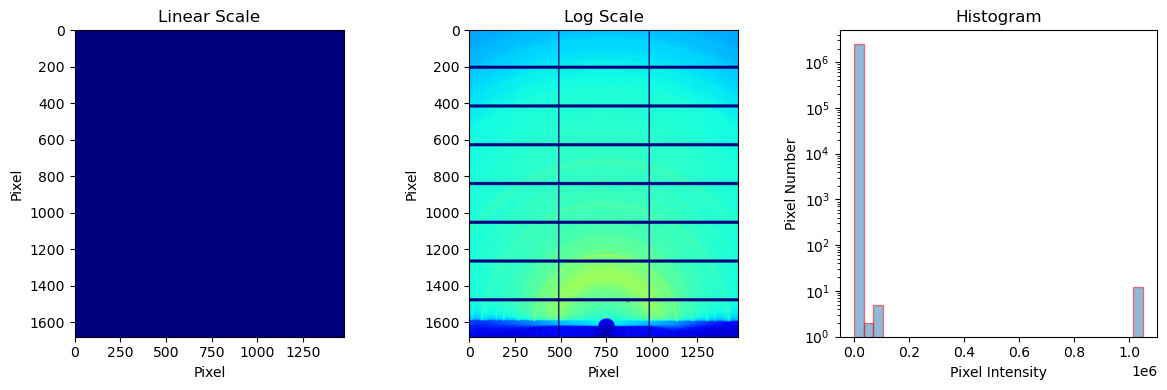

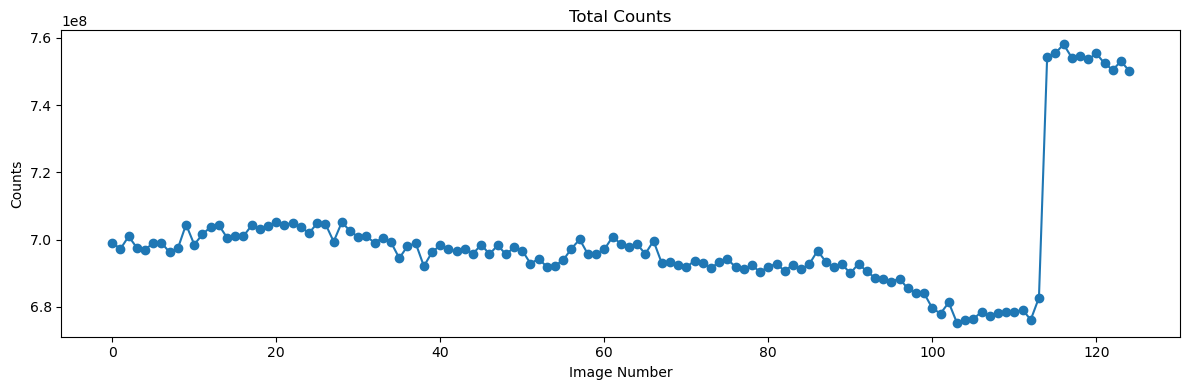

In [10]:
folder = Path(r"C:\Users\lheald\Box\TRXRDPython\testdata\detimages")
file_names = sorted([f for f in folder.iterdir() if f.suffix.lower() == ".tif"])

print(f"{len(file_names)} TIFF files found in {folder}.")

data_dict = get_image_details(file_names, sort=True, filter_data=False, plot=True)

## Apply Mask to Data

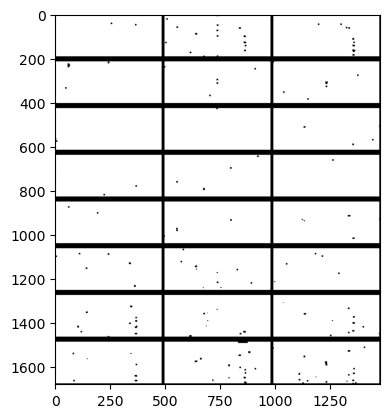

In [11]:
mask_file = tf.imread("C:\\Users\\lheald\\Box\\TRXRDPython\\testdata\\mask_2021_dec.tif")

plt.imshow(mask_file, cmap="gray")

In [12]:
def apply_nan_mask(data_array, mask_path, plot=False, image_index=0, figsize=(10, 4)):
    """
    Apply a binary mask to image data, replacing masked pixels with NaN.

    Parameters
    ----------
    data_array : np.ndarray
        Input image data, either:
        - 2D: (rows, cols)
        - 3D: (n_images, rows, cols)
    mask_path : str or Path
        Path to a mask file containing 0s and 1s.
        Pixels where mask == 1 are replaced with NaN.
    plot : bool, optional
        If True, plot an example original image and masked image.
    image_index : int, optional
        Which image to plot if `data_array` is 3D.
    figsize : tuple, optional
        Figure size for the example plot.

    Returns
    -------
    masked_data : np.ndarray
        Float copy of input data with masked pixels set to NaN.

    Raises
    ------
    ValueError
        If input dimensions are invalid or mask shape does not match image shape.
    """
    mask = tf.imread(Path(mask_path))
    mask_bool = mask == 0

    if data_array.ndim == 2:
        if data_array.shape != mask_bool.shape:
            raise ValueError(
                f"Mask shape {mask_bool.shape} does not match image shape {data_array.shape}."
            )

        original_image = data_array
        masked_data = data_array.astype(float, copy=True)
        masked_data[mask_bool] = np.nan
        masked_image = masked_data

    elif data_array.ndim == 3:
        if data_array.shape[1:] != mask_bool.shape:
            raise ValueError(
                f"Mask shape {mask_bool.shape} does not match image shape {data_array.shape[1:]}."
            )

        if not (0 <= image_index < data_array.shape[0]):
            raise ValueError(
                f"image_index={image_index} is out of bounds for {data_array.shape[0]} images."
            )

        original_image = data_array[image_index]
        masked_data = data_array.astype(float, copy=True)
        masked_data[:, mask_bool] = np.nan
        masked_image = masked_data[image_index]

    else:
        raise ValueError("data_array must be 2D or 3D.")

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=figsize)

        im0 = axes[0].imshow(original_image, cmap="jet")
        axes[0].set_title("Original Image")
        axes[0].set_xlabel("Pixel")
        axes[0].set_ylabel("Pixel")
        plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

        im1 = axes[1].imshow(masked_image, cmap="jet")
        axes[1].set_title("Masked Image")
        axes[1].set_xlabel("Pixel")
        axes[1].set_ylabel("Pixel")
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

    return masked_data



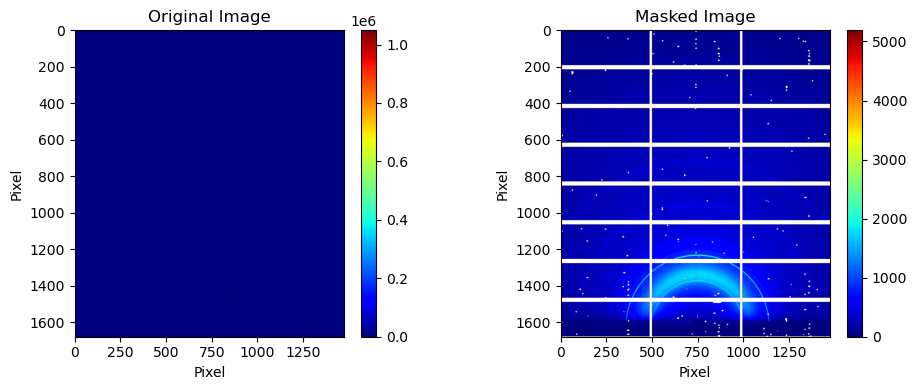

In [13]:
mask_file = "C:\\Users\\lheald\\Box\\TRXRDPython\\testdata\\mask_2021_dec.tif"
masked_data = apply_nan_mask(data_dict["images"], mask_path=mask_file, plot=True) 
masked_dict = {"images": masked_data, "fluence": data_dict["fluence"], "delay": data_dict["delay"], "image_number": data_dict["image_number"], "counts": data_dict["counts"]}
del data_dict

## Find Image Centers

### Slow Version

In [23]:
def _prepare_valid_pixel_subset(image, mask=None, intensity_threshold=None, top_percentile=None):
    """
    Prepare a subset of valid pixels for faster radial-profile calculations.

    Parameters
    ----------
    image : np.ndarray
        2D image.
    mask : np.ndarray or None
        Boolean mask where True means invalid pixel.
    intensity_threshold : float or None
        Keep only pixels with intensity >= this value.
    top_percentile : float or None
        Keep only pixels at or above this percentile of valid intensities.
        Example: 90 means keep brightest 10 percent of valid pixels.

    Returns
    -------
    yy : np.ndarray
        y coordinates of selected valid pixels.
    xx : np.ndarray
        x coordinates of selected valid pixels.
    vals : np.ndarray
        Intensity values of selected valid pixels.
    """
    if image.ndim != 2:
        raise ValueError("image must be 2D.")

    img = image.astype(float, copy=False)

    valid = ~np.isnan(img)
    if mask is not None:
        if mask.shape != img.shape:
            raise ValueError("mask must have same shape as image.")
        valid &= ~mask.astype(bool)

    if not np.any(valid):
        raise ValueError("No valid pixels available.")

    if top_percentile is not None:
        thresh = np.percentile(img[valid], top_percentile)
        valid &= img >= thresh

    if intensity_threshold is not None:
        valid &= img >= intensity_threshold

    if not np.any(valid):
        raise ValueError("No pixels remain after brightness filtering.")

    yy, xx = np.nonzero(valid)
    vals = img[yy, xx]
    return yy.astype(float), xx.astype(float), vals


def _radial_profile_from_subset(yy, xx, vals, center_yx):
    """
    Compute radial average profile from a preselected subset of pixels.

    Parameters
    ----------
    yy, xx : np.ndarray
        Pixel coordinates.
    vals : np.ndarray
        Pixel intensities.
    center_yx : tuple
        Center as (cy, cx).

    Returns
    -------
    r : np.ndarray
        Integer radius values.
    radial_mean : np.ndarray
        Mean intensity at each radius.
    """
    cy, cx = center_yx
    rr = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2).astype(np.int32)

    radial_sum = np.bincount(rr, weights=vals)
    radial_count = np.bincount(rr)
    radial_mean = radial_sum / np.maximum(radial_count, 1)

    return np.arange(len(radial_mean)), radial_mean


def _profile_sharpness_score(profile):
    """
    Score a radial profile by gradient energy.
    """
    if len(profile) < 3:
        return -np.inf
    grad = np.gradient(profile)
    return np.sum(grad ** 2)


def find_diffraction_center_from_guess_radial_fast(
    image,
    center_guess,
    search_radius=20,
    mask=None,
    r_min=0,
    r_max=None,
    downsample=1,
    intensity_threshold=None,
    top_percentile=None,
    plot=False,
    figsize=(15, 4),
):
    """
    Faster diffraction-center refinement using radial-profile sharpness.

    Parameters
    ----------
    image : np.ndarray
        2D diffraction image.
    center_guess : tuple
        Initial guess as (cy, cx).
    search_radius : int
        Search radius around guessed center.
    mask : np.ndarray or None
        Boolean mask where True means invalid.
    r_min : int
        Minimum radius for scoring.
    r_max : int or None
        Maximum radius for scoring.
    downsample : int
        Optional integer downsampling factor. 1 means no downsampling.
    intensity_threshold : float or None
        Keep only pixels with intensity >= this threshold.
    top_percentile : float or None
        Keep only pixels at or above this percentile.
    plot : bool
        If True, make diagnostic plots.
    figsize : tuple
        Figure size.

    Returns
    -------
    results : dict
    """
    if image.ndim != 2:
        raise ValueError("image must be 2D.")
    if downsample < 1 or int(downsample) != downsample:
        raise ValueError("downsample must be an integer >= 1.")

    downsample = int(downsample)

    img = image.astype(float, copy=False)

    if downsample > 1:
        img_work = img[::downsample, ::downsample]
        mask_work = None if mask is None else mask[::downsample, ::downsample]
        guess_y = center_guess[0] / downsample
        guess_x = center_guess[1] / downsample
        search_radius_work = max(1, int(np.ceil(search_radius / downsample)))
        r_min_work = r_min / downsample
        r_max_work = None if r_max is None else r_max / downsample
    else:
        img_work = img
        mask_work = mask
        guess_y, guess_x = center_guess
        search_radius_work = search_radius
        r_min_work = r_min
        r_max_work = r_max

    yy, xx, vals = _prepare_valid_pixel_subset(
        img_work,
        mask=mask_work,
        intensity_threshold=intensity_threshold,
        top_percentile=top_percentile,
    )

    cy_values = np.arange(
        int(np.round(guess_y)) - search_radius_work,
        int(np.round(guess_y)) + search_radius_work + 1,
    )
    cx_values = np.arange(
        int(np.round(guess_x)) - search_radius_work,
        int(np.round(guess_x)) + search_radius_work + 1,
    )

    score_map = np.full((len(cy_values), len(cx_values)), -np.inf, dtype=float)

    best_score = -np.inf
    best_center = None
    best_r = None
    best_profile = None

    for i, cy in enumerate(cy_values):
        for j, cx in enumerate(cx_values):
            r, profile = _radial_profile_from_subset(yy, xx, vals, (cy, cx))

            if r_max_work is None:
                keep = r >= r_min_work
            else:
                keep = (r >= r_min_work) & (r <= r_max_work)

            profile_use = profile[keep]
            if len(profile_use) < 3:
                continue

            score = _profile_sharpness_score(profile_use)
            score_map[i, j] = score

            if score > best_score:
                best_score = score
                best_center = (cy, cx)
                best_r = r
                best_profile = profile

    if best_center is None:
        raise RuntimeError("Could not determine a valid center.")

    best_cy_work, best_cx_work = best_center

    if downsample > 1:
        best_center_full = (best_cy_work * downsample, best_cx_work * downsample)
        best_r_full = best_r * downsample
        cy_values_full = cy_values * downsample
        cx_values_full = cx_values * downsample
    else:
        best_center_full = best_center
        best_r_full = best_r
        cy_values_full = cy_values
        cx_values_full = cx_values

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=figsize)

        img_plot = np.nan_to_num(img, nan=0.0)

        axes[0].imshow(img_plot, cmap="inferno")
        axes[0].plot(center_guess[1], center_guess[0], "co", label="Guess")
        axes[0].plot(best_center_full[1], best_center_full[0], "r+", ms=12, mew=2, label="Best")
        axes[0].set_title("Image with Center")
        axes[0].legend()

        im = axes[1].imshow(
            score_map,
            origin="lower",
            aspect="auto",
            extent=[cx_values_full[0], cx_values_full[-1], cy_values_full[0], cy_values_full[-1]],
            cmap="viridis",
        )
        axes[1].plot(center_guess[1], center_guess[0], "co", label="Guess")
        axes[1].plot(best_center_full[1], best_center_full[0], "r+", ms=12, mew=2, label="Best")
        axes[1].set_xlabel("cx")
        axes[1].set_ylabel("cy")
        axes[1].set_title("Score Map")
        axes[1].legend()
        plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

        axes[2].plot(best_r_full, best_profile)
        axes[2].set_xlabel("Radius (pixels)")
        axes[2].set_ylabel("Mean intensity")
        axes[2].set_title("Best Radial Profile")

        if r_min > 0:
            axes[2].axvline(r_min, color="gray", linestyle="--")
        if r_max is not None:
            axes[2].axvline(r_max, color="gray", linestyle="--")

        plt.tight_layout()
        plt.show()

    return {
        "center_yx": best_center_full,
        "score": best_score,
        "score_map": score_map,
        "cy_values": cy_values_full,
        "cx_values": cx_values_full,
        "r": best_r_full,
        "radial_profile": best_profile,
        "downsample": downsample,
    }


def find_centers_in_stack_radial_fast(
    data_array,
    center_guess,
    search_radius=20,
    mask=None,
    r_min=0,
    r_max=None,
    downsample=1,
    intensity_threshold=None,
    top_percentile=None,
    use_previous_center=True,
    plot_example=False,
    example_index=0,
    plot_center_vs_image=False,
    image_numbers=None,
    figsize_example=(15, 4),
    figsize_trend=(10, 6),
):
    """
    Find diffraction centers across an image stack more quickly.

    Improvements:
    - optional downsampling
    - optional bright-pixel filtering
    - optional use of previous center as next guess

    Parameters
    ----------
    data_array : np.ndarray
        3D array of shape (n_images, rows, cols).
    center_guess : tuple
        Initial guess as (cy, cx).
    search_radius : int
        Search radius around guessed center.
    mask : np.ndarray or None
        Boolean 2D mask.
    r_min : int
        Minimum radius for scoring.
    r_max : int or None
        Maximum radius for scoring.
    downsample : int
        Integer downsampling factor.
    intensity_threshold : float or None
        Keep pixels above this threshold.
    top_percentile : float or None
        Keep pixels above this percentile.
    use_previous_center : bool
        If True, use previous result as next initial guess.
    plot_example : bool
        Plot one example result.
    example_index : int
        Index to plot.
    plot_center_vs_image : bool
        Plot center trend over stack.
    image_numbers : np.ndarray or None
        Optional x-axis values.
    figsize_example : tuple
        Figure size for example plot.
    figsize_trend : tuple
        Figure size for trend plot.

    Returns
    -------
    results : dict
    """
    if data_array.ndim != 3:
        raise ValueError("data_array must be 3D with shape (n_images, rows, cols).")

    n_images = data_array.shape[0]

    center_y = np.empty(n_images, dtype=float)
    center_x = np.empty(n_images, dtype=float)
    score = np.empty(n_images, dtype=float)

    example_result = None
    current_guess = center_guess

    for idx in range(n_images):
        result = find_diffraction_center_from_guess_radial_fast(
            image=data_array[idx],
            center_guess=current_guess,
            search_radius=search_radius,
            mask=mask,
            r_min=r_min,
            r_max=r_max,
            downsample=downsample,
            intensity_threshold=intensity_threshold,
            top_percentile=top_percentile,
            plot=False,
        )

        cy, cx = result["center_yx"]
        center_y[idx] = cy
        center_x[idx] = cx
        score[idx] = result["score"]
        if idx%10 == 0:
            print(f"Found center for image {idx}: (cy={cy:.2f}, cx={cx:.2f}), score={score[idx]:.2f}")

        if use_previous_center:
            current_guess = (cy, cx)

        if idx == example_index:
            example_result = result

    image_index = np.arange(n_images)

    if plot_example:
        if not (0 <= example_index < n_images):
            raise ValueError("example_index is out of bounds.")

        img = data_array[example_index].astype(float)
        img_plot = np.nan_to_num(img, nan=0.0)

        fig, axes = plt.subplots(1, 3, figsize=figsize_example)

        axes[0].imshow(img_plot, cmap="inferno")
        axes[0].plot(center_guess[1], center_guess[0], "co", label="Initial guess")
        axes[0].plot(center_x[example_index], center_y[example_index], "r+", ms=12, mew=2, label="Best")
        axes[0].set_title("Example Image")
        axes[0].legend()

        im = axes[1].imshow(
            example_result["score_map"],
            origin="lower",
            aspect="auto",
            extent=[
                example_result["cx_values"][0],
                example_result["cx_values"][-1],
                example_result["cy_values"][0],
                example_result["cy_values"][-1],
            ],
            cmap="viridis",
        )
        axes[1].plot(center_x[example_index], center_y[example_index], "r+", ms=12, mew=2, label="Best")
        axes[1].set_xlabel("cx")
        axes[1].set_ylabel("cy")
        axes[1].set_title("Score Map")
        axes[1].legend()
        plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

        axes[2].plot(example_result["r"], example_result["radial_profile"])
        axes[2].set_xlabel("Radius (pixels)")
        axes[2].set_ylabel("Mean intensity")
        axes[2].set_title("Best Radial Profile")

        if r_min > 0:
            axes[2].axvline(r_min, color="gray", linestyle="--")
        if r_max is not None:
            axes[2].axvline(r_max, color="gray", linestyle="--")

        plt.tight_layout()
        plt.show()

    if plot_center_vs_image:
        xvals = image_numbers if image_numbers is not None else image_index
        xlabel = "Image number" if image_numbers is not None else "Image index"

        fig, axes = plt.subplots(2, 1, figsize=figsize_trend, sharex=True)

        axes[0].plot(xvals, center_x, "o-")
        axes[0].set_ylabel("Center x (pixels)")
        axes[0].set_title("Center Position vs Image")
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(xvals, center_y, "o-", color="tab:orange")
        axes[1].set_xlabel(xlabel)
        axes[1].set_ylabel("Center y (pixels)")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return {
        "center_y": center_y,
        "center_x": center_x,
        "score": score,
        "image_index": image_index,
    }


Found center for image 0: (cy=1623.00, cx=746.00), score=1669991.08
Found center for image 10: (cy=1622.00, cx=745.00), score=1701893.85
Found center for image 20: (cy=1622.00, cx=746.00), score=1805400.41
Found center for image 30: (cy=1564.00, cx=746.00), score=11583516.72
Found center for image 40: (cy=1564.00, cx=746.00), score=11466752.82
Found center for image 50: (cy=1564.00, cx=746.00), score=10646018.94
Found center for image 60: (cy=1564.00, cx=746.00), score=11387837.84
Found center for image 70: (cy=1564.00, cx=746.00), score=10517509.67
Found center for image 80: (cy=1564.00, cx=746.00), score=11042382.40
Found center for image 90: (cy=1564.00, cx=746.00), score=11656732.03
Found center for image 100: (cy=1564.00, cx=746.00), score=9848687.57
Found center for image 110: (cy=1564.00, cx=746.00), score=10757749.94
Found center for image 120: (cy=1564.00, cx=746.00), score=12909617.24


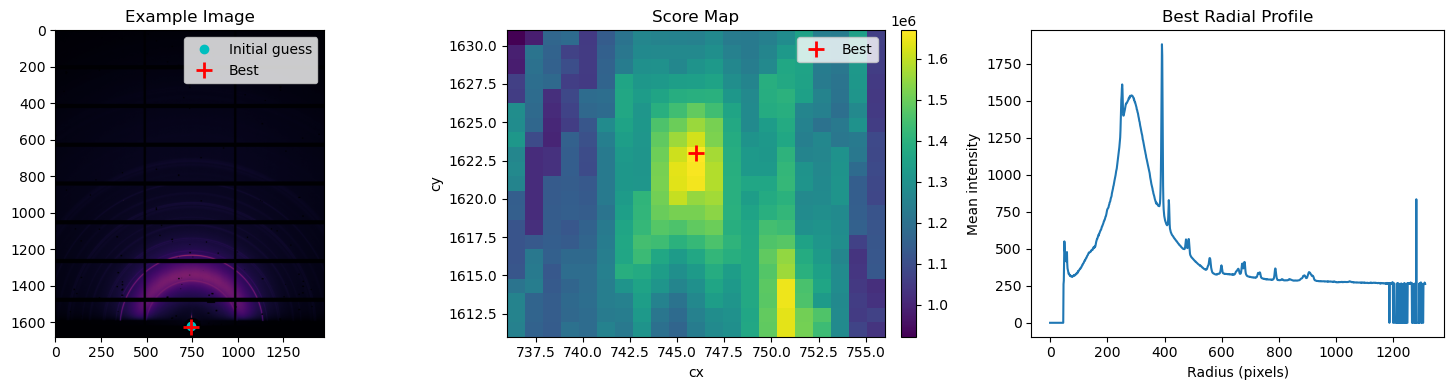

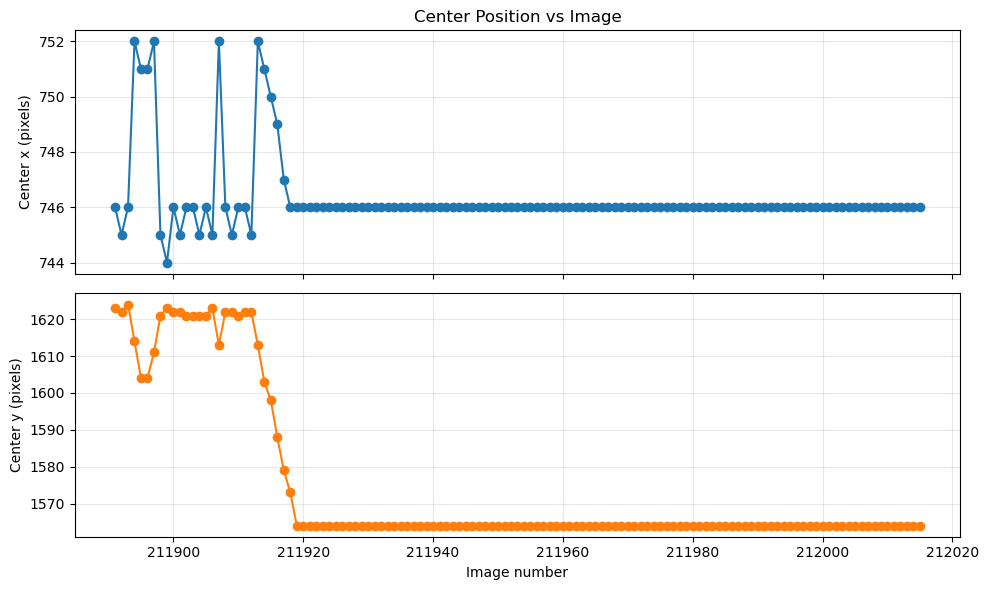

In [27]:
center_y, center_x, score, image_index = find_centers_in_stack_radial_fast(masked_dict["images"], center_guess=(1621.0, 746.25), 
                                                                           search_radius=10, mask=None, r_min=0, r_max=None,
                                                                           downsample=1, intensity_threshold=None, top_percentile=60, 
                                                                           use_previous_center=True, plot_example=True, example_index=0, plot_center_vs_image=True,
                                                                           image_numbers=masked_dict["image_number"])

### Faster Parallel Version

In [31]:
def _prepare_valid_pixel_subset(image, mask=None, intensity_threshold=None, top_percentile=None):
    """
    Prepare a subset of valid pixels for faster radial-profile calculations.

    Parameters
    ----------
    image : np.ndarray
        2D image.
    mask : np.ndarray or None
        Boolean mask where True means invalid pixel.
    intensity_threshold : float or None
        Keep only pixels with intensity >= this value.
    top_percentile : float or None
        Keep only pixels at or above this percentile of valid intensities.

    Returns
    -------
    yy : np.ndarray
        y coordinates of selected valid pixels.
    xx : np.ndarray
        x coordinates of selected valid pixels.
    vals : np.ndarray
        Intensity values of selected valid pixels.
    """
    if image.ndim != 2:
        raise ValueError("image must be 2D.")

    img = image.astype(float, copy=False)

    valid = ~np.isnan(img)
    if mask is not None:
        if mask.shape != img.shape:
            raise ValueError("mask must have same shape as image.")
        valid &= ~mask.astype(bool)

    if not np.any(valid):
        raise ValueError("No valid pixels available.")

    if top_percentile is not None:
        thresh = np.percentile(img[valid], top_percentile)
        valid &= img >= thresh

    if intensity_threshold is not None:
        valid &= img >= intensity_threshold

    if not np.any(valid):
        raise ValueError("No pixels remain after brightness filtering.")

    yy, xx = np.nonzero(valid)
    vals = img[yy, xx]
    return yy.astype(float), xx.astype(float), vals


def _radial_profile_from_subset(yy, xx, vals, center_yx):
    """
    Compute radial average profile from a preselected subset of pixels.

    Parameters
    ----------
    yy, xx : np.ndarray
        Pixel coordinates.
    vals : np.ndarray
        Pixel intensities.
    center_yx : tuple
        Center as (cy, cx).

    Returns
    -------
    r : np.ndarray
        Integer radius values.
    radial_mean : np.ndarray
        Mean intensity at each radius.
    """
    cy, cx = center_yx
    rr = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2).astype(np.int32)

    radial_sum = np.bincount(rr, weights=vals)
    radial_count = np.bincount(rr)
    radial_mean = radial_sum / np.maximum(radial_count, 1)

    return np.arange(len(radial_mean)), radial_mean


def _profile_sharpness_score(profile):
    """
    Score a radial profile by gradient energy.
    """
    if len(profile) < 3:
        return -np.inf
    grad = np.gradient(profile)
    return np.sum(grad ** 2)


def find_diffraction_center_from_guess_radial_fast(
    image,
    center_guess,
    search_radius=20,
    mask=None,
    r_min=0,
    r_max=None,
    downsample=1,
    intensity_threshold=None,
    top_percentile=None,
    plot=False,
    figsize=(15, 4),
):
    """
    Find diffraction center for one image using radial-profile sharpness.

    Parameters
    ----------
    image : np.ndarray
        2D diffraction image.
    center_guess : tuple
        Initial guess as (cy, cx).
    search_radius : int
        Search radius around guessed center.
    mask : np.ndarray or None
        Boolean mask where True means invalid.
    r_min : int
        Minimum radius for scoring.
    r_max : int or None
        Maximum radius for scoring.
    downsample : int
        Integer downsampling factor. 1 means no downsampling.
    intensity_threshold : float or None
        Keep only pixels with intensity >= this threshold.
    top_percentile : float or None
        Keep only pixels at or above this percentile.
    plot : bool
        If True, make diagnostic plots.
    figsize : tuple
        Figure size.

    Returns
    -------
    results : dict
        Dictionary containing center, score, score map, and radial profile.
    """
    if image.ndim != 2:
        raise ValueError("image must be 2D.")
    if downsample < 1 or int(downsample) != downsample:
        raise ValueError("downsample must be an integer >= 1.")

    downsample = int(downsample)
    img = image.astype(float, copy=False)

    if downsample > 1:
        img_work = img[::downsample, ::downsample]
        mask_work = None if mask is None else mask[::downsample, ::downsample]
        guess_y = center_guess[0] / downsample
        guess_x = center_guess[1] / downsample
        search_radius_work = max(1, int(np.ceil(search_radius / downsample)))
        r_min_work = r_min / downsample
        r_max_work = None if r_max is None else r_max / downsample
    else:
        img_work = img
        mask_work = mask
        guess_y, guess_x = center_guess
        search_radius_work = search_radius
        r_min_work = r_min
        r_max_work = r_max

    yy, xx, vals = _prepare_valid_pixel_subset(
        img_work,
        mask=mask_work,
        intensity_threshold=intensity_threshold,
        top_percentile=top_percentile,
    )

    cy_values = np.arange(
        int(np.round(guess_y)) - search_radius_work,
        int(np.round(guess_y)) + search_radius_work + 1,
    )
    cx_values = np.arange(
        int(np.round(guess_x)) - search_radius_work,
        int(np.round(guess_x)) + search_radius_work + 1,
    )

    score_map = np.full((len(cy_values), len(cx_values)), -np.inf, dtype=float)

    best_score = -np.inf
    best_center = None
    best_r = None
    best_profile = None

    for i, cy in enumerate(cy_values):
        for j, cx in enumerate(cx_values):
            r, profile = _radial_profile_from_subset(yy, xx, vals, (cy, cx))

            if r_max_work is None:
                keep = r >= r_min_work
            else:
                keep = (r >= r_min_work) & (r <= r_max_work)

            profile_use = profile[keep]
            if len(profile_use) < 3:
                continue

            score = _profile_sharpness_score(profile_use)
            score_map[i, j] = score

            if score > best_score:
                best_score = score
                best_center = (cy, cx)
                best_r = r
                best_profile = profile

    if best_center is None:
        raise RuntimeError("Could not determine a valid center.")

    best_cy_work, best_cx_work = best_center

    if downsample > 1:
        best_center_full = (best_cy_work * downsample, best_cx_work * downsample)
        best_r_full = best_r * downsample
        cy_values_full = cy_values * downsample
        cx_values_full = cx_values * downsample
    else:
        best_center_full = best_center
        best_r_full = best_r
        cy_values_full = cy_values
        cx_values_full = cx_values

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=figsize)

        img_plot = np.nan_to_num(img, nan=0.0)

        axes[0].imshow(img_plot, cmap="inferno")
        axes[0].plot(center_guess[1], center_guess[0], "co", label="Guess")
        axes[0].plot(best_center_full[1], best_center_full[0], "r+", ms=12, mew=2, label="Best")
        axes[0].set_title("Image with Center")
        axes[0].legend()

        im = axes[1].imshow(
            score_map,
            origin="lower",
            aspect="auto",
            extent=[cx_values_full[0], cx_values_full[-1], cy_values_full[0], cy_values_full[-1]],
            cmap="viridis",
        )
        axes[1].plot(center_guess[1], center_guess[0], "co", label="Guess")
        axes[1].plot(best_center_full[1], best_center_full[0], "r+", ms=12, mew=2, label="Best")
        axes[1].set_xlabel("cx")
        axes[1].set_ylabel("cy")
        axes[1].set_title("Score Map")
        axes[1].legend()
        plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

        axes[2].plot(best_r_full, best_profile)
        axes[2].set_xlabel("Radius (pixels)")
        axes[2].set_ylabel("Mean intensity")
        axes[2].set_title("Best Radial Profile")

        if r_min > 0:
            axes[2].axvline(r_min, color="gray", linestyle="--")
        if r_max is not None:
            axes[2].axvline(r_max, color="gray", linestyle="--")

        plt.tight_layout()
        plt.show()

    return {
        "center_yx": best_center_full,
        "score": best_score,
        "score_map": score_map,
        "cy_values": cy_values_full,
        "cx_values": cx_values_full,
        "r": best_r_full,
        "radial_profile": best_profile,
    }


def _center_worker(
    idx,
    image,
    center_guess,
    search_radius,
    mask,
    r_min,
    r_max,
    downsample,
    intensity_threshold,
    top_percentile,
):
    """
    Worker for one image, suitable for parallel execution.
    """
    result = find_diffraction_center_from_guess_radial_fast(
        image=image,
        center_guess=center_guess,
        search_radius=search_radius,
        mask=mask,
        r_min=r_min,
        r_max=r_max,
        downsample=downsample,
        intensity_threshold=intensity_threshold,
        top_percentile=top_percentile,
        plot=False,
    )

    cy, cx = result["center_yx"]
    return {
        "index": idx,
        "center_y": cy,
        "center_x": cx,
        "score": result["score"],
        "full_result": result,
    }


def find_centers_in_stack_radial_parallel(
    data_array,
    center_guess,
    search_radius=20,
    mask=None,
    r_min=0,
    r_max=None,
    downsample=1,
    intensity_threshold=None,
    top_percentile=None,
    n_jobs=-1,
    backend="loky",
    verbose=10,
    plot_example=False,
    example_index=0,
    plot_center_vs_image=False,
    image_numbers=None,
    figsize_example=(15, 4),
    figsize_trend=(10, 6),
):
    """
    Find diffraction centers for a stack of images in parallel using
    an independent fixed guess for each image.

    Parameters
    ----------
    data_array : np.ndarray
        3D array of shape (n_images, rows, cols).
    center_guess : tuple
        Fixed center guess as (cy, cx) used for every image.
    search_radius : int
        Search radius around guessed center.
    mask : np.ndarray or None
        Boolean 2D mask where True means invalid.
    r_min : int
        Minimum radius for scoring.
    r_max : int or None
        Maximum radius for scoring.
    downsample : int
        Integer downsampling factor.
    intensity_threshold : float or None
        Keep pixels above this threshold.
    top_percentile : float or None
        Keep pixels at or above this percentile.
    n_jobs : int
        Number of parallel jobs. -1 uses all available cores.
    backend : str
        Joblib backend, usually "loky" or "threading".
    verbose : int
        Joblib verbosity.
    plot_example : bool
        If True, plot one example result.
    example_index : int
        Which image to use for the example plot.
    plot_center_vs_image : bool
        If True, plot center_x and center_y versus image number/index.
    image_numbers : np.ndarray or None
        X-axis values for trend plots. If None, uses image indices.
    figsize_example : tuple
        Figure size for example plot.
    figsize_trend : tuple
        Figure size for trend plot.

    Returns
    -------
    results : dict
        Dictionary containing:
        - "center_y": np.ndarray
        - "center_x": np.ndarray
        - "score": np.ndarray
        - "image_index": np.ndarray
        - "per_image_results": list
    """
    if data_array.ndim != 3:
        raise ValueError("data_array must be 3D with shape (n_images, rows, cols).")

    n_images = data_array.shape[0]

    worker_outputs = Parallel(n_jobs=n_jobs, backend=backend, verbose=verbose)(
        delayed(_center_worker)(
            idx=idx,
            image=data_array[idx],
            center_guess=center_guess,
            search_radius=search_radius,
            mask=mask,
            r_min=r_min,
            r_max=r_max,
            downsample=downsample,
            intensity_threshold=intensity_threshold,
            top_percentile=top_percentile,
        )
        for idx in range(n_images)
    )

    worker_outputs = sorted(worker_outputs, key=lambda d: d["index"])

    center_y = np.array([d["center_y"] for d in worker_outputs], dtype=float)
    center_x = np.array([d["center_x"] for d in worker_outputs], dtype=float)
    score = np.array([d["score"] for d in worker_outputs], dtype=float)
    image_index = np.arange(n_images)
    per_image_results = [d["full_result"] for d in worker_outputs]

    if plot_example:
        if not (0 <= example_index < n_images):
            raise ValueError("example_index is out of bounds.")

        example_result = per_image_results[example_index]
        img = data_array[example_index].astype(float)
        img_plot = np.nan_to_num(img, nan=0.0)

        fig, axes = plt.subplots(1, 3, figsize=figsize_example)

        axes[0].imshow(img_plot, cmap="inferno")
        axes[0].plot(center_guess[1], center_guess[0], "co", label="Fixed guess")
        axes[0].plot(center_x[example_index], center_y[example_index], "r+", ms=12, mew=2, label="Best")
        axes[0].set_title(f"Example Image {example_index}")
        axes[0].legend()

        im = axes[1].imshow(
            example_result["score_map"],
            origin="lower",
            aspect="auto",
            extent=[
                example_result["cx_values"][0],
                example_result["cx_values"][-1],
                example_result["cy_values"][0],
                example_result["cy_values"][-1],
            ],
            cmap="viridis",
        )
        axes[1].plot(center_guess[1], center_guess[0], "co", label="Fixed guess")
        axes[1].plot(center_x[example_index], center_y[example_index], "r+", ms=12, mew=2, label="Best")
        axes[1].set_xlabel("cx")
        axes[1].set_ylabel("cy")
        axes[1].set_title("Score Map")
        axes[1].legend()
        plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

        axes[2].plot(example_result["r"], example_result["radial_profile"])
        axes[2].set_xlabel("Radius (pixels)")
        axes[2].set_ylabel("Mean intensity")
        axes[2].set_title("Best Radial Profile")

        if r_min > 0:
            axes[2].axvline(r_min, color="gray", linestyle="--")
        if r_max is not None:
            axes[2].axvline(r_max, color="gray", linestyle="--")

        plt.tight_layout()
        plt.show()

    if plot_center_vs_image:
        xvals = image_numbers if image_numbers is not None else image_index
        xlabel = "Image number" if image_numbers is not None else "Image index"

        fig, axes = plt.subplots(2, 1, figsize=figsize_trend, sharex=True)

        axes[0].plot(xvals, center_x, "o-")
        axes[0].set_ylabel("Center x (pixels)")
        axes[0].set_title("Center Position vs Image")
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(xvals, center_y, "o-", color="tab:orange")
        axes[1].set_xlabel(xlabel)
        axes[1].set_ylabel("Center y (pixels)")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return {
        "center_y": center_y,
        "center_x": center_x,
        "score": score,
        "image_index": image_index,
        "per_image_results": per_image_results,
    }


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   31.4s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   58.1s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 107 out of 125 | elapsed:  3.6min remaining:   36.0s
[Parallel(n_jobs=-1)]: Done 120 out of 125 | elapsed:  3.9min remaining:    9.6s
[Parallel(n_jobs=-1)]: Done 125 out of 125 | elapsed:  3.9min finished


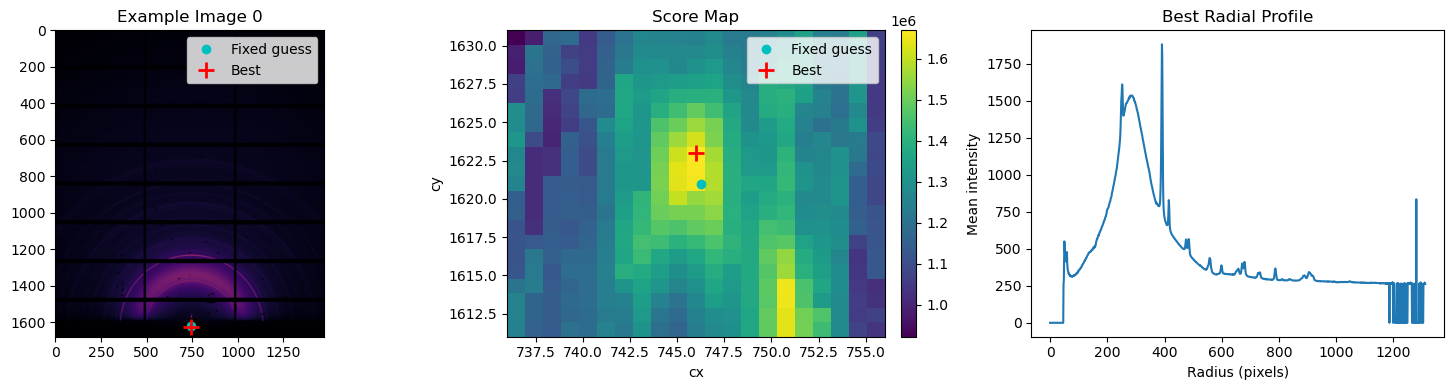

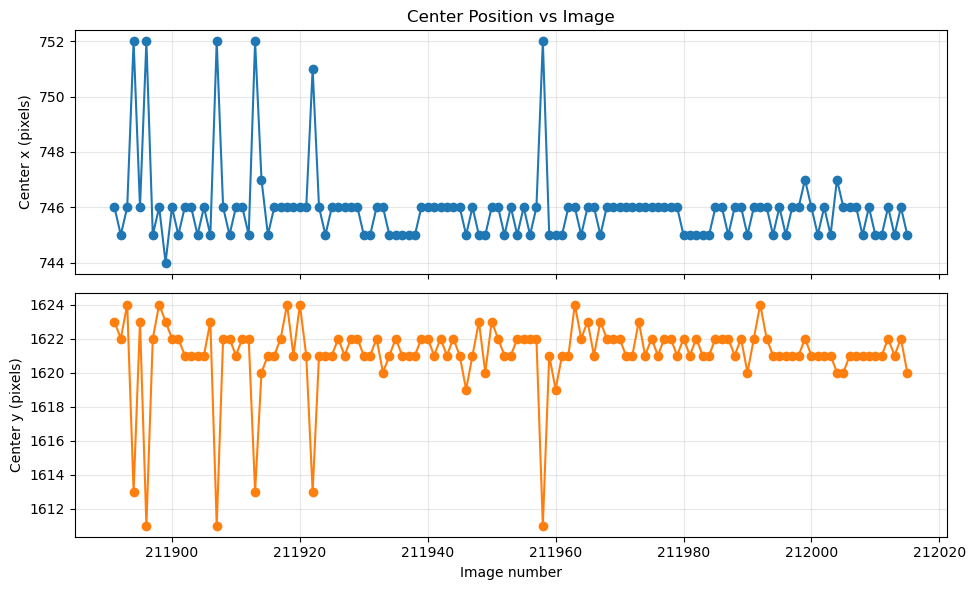

In [32]:
center_dict = find_centers_in_stack_radial_parallel(masked_dict["images"], center_guess=(1621.0, 746.25),
                                                   search_radius=10, mask=None, r_min=0, r_max=None, 
                                                   downsample=1, intensity_threshold=None, top_percentile=60,
                                                   n_jobs=-1, backend="loky", verbose=10, plot_example=True, 
                                                   example_index=0, plot_center_vs_image=True, 
                                                   image_numbers=masked_dict["image_number"])

## Get Azimuthal Average using pyFAI

In [43]:
# ============================================================
# Global detector / beam configuration
# Edit these defaults for your instrument
# ============================================================
PIXEL1 = 1.72e-4                 # m, detector pixel size along rows (y)
PIXEL2 = 1.72e-4                 # m, detector pixel size along cols (x)
DISTANCE = 0.1887413                 # m, sample-to-detector distance
WAVELENGTH = 1.0596937286439283e-10          # m

# Detector orientation
TILT_ANGLE = np.deg2rad(-0.16433)               # rad
TILT_PLANE_ROTATION = np.deg2rad(72.122779)      # rad
ROT3 = 0.0                      # rad, in-plane detector rotation

# Optional corrections
POLARIZATION_FACTOR = None      # e.g. 0.99 or None
DARK = None                     # 2D dark image or None
FLAT = None                     # 2D flat-field image or None


def normalize_centers(centers, n_images, use_average_center=False):
    """
    Normalize center input into an array of shape (n_images, 2).

    Parameters
    ----------
    centers : tuple, list, or ndarray
        Either:
        - one center: (x_center, y_center)
        - one center per image: shape (n_images, 2)
    n_images : int
        Number of images.
    use_average_center : bool, optional
        If True and centers has shape (n_images, 2), replace all centers
        by the average center.

    Returns
    -------
    centers_out : ndarray
        Array of shape (n_images, 2).
    """
    centers = np.asarray(centers, dtype=float)

    if centers.shape == (2,):
        centers_out = np.tile(centers, (n_images, 1))
    elif centers.shape == (n_images, 2):
        if use_average_center:
            avg_center = np.nanmean(centers, axis=0)
            centers_out = np.tile(avg_center, (n_images, 1))
        else:
            centers_out = centers
    else:
        raise ValueError("centers must have shape (2,) or (n_images, 2)")

    return centers_out


def tilt_to_rotations(tilt_angle, tilt_plane_rotation, rot3=0.0):
    """
    Approximate conversion from detector tilt description to
    pyFAI rotation parameters.

    Parameters
    ----------
    tilt_angle : float
        Detector tilt angle in radians.
    tilt_plane_rotation : float
        Angle of the tilt plane in radians.
    rot3 : float, optional
        In-plane detector rotation in radians.

    Returns
    -------
    rot1 : float
        pyFAI rotation parameter.
    rot2 : float
        pyFAI rotation parameter.
    rot3 : float
        pyFAI in-plane rotation parameter.
    """
    rot1 = tilt_angle * np.cos(tilt_plane_rotation)
    rot2 = tilt_angle * np.sin(tilt_plane_rotation)
    return rot1, rot2, rot3


def make_azimuthal_integrator(
    center,
    pixel1=PIXEL1,
    pixel2=PIXEL2,
    distance=DISTANCE,
    wavelength=WAVELENGTH,
    tilt_angle=TILT_ANGLE,
    tilt_plane_rotation=TILT_PLANE_ROTATION,
    rot3=ROT3,
):
    """
    Create a pyFAI AzimuthalIntegrator for a given beam center.

    Parameters
    ----------
    center : tuple or array-like
        (x_center, y_center) in pixel coordinates.
    pixel1, pixel2 : float, optional
        Pixel sizes in meters.
    distance : float, optional
        Sample-detector distance in meters.
    wavelength : float, optional
        Beam wavelength in meters.
    tilt_angle : float, optional
        Detector tilt angle in radians.
    tilt_plane_rotation : float, optional
        Tilt plane rotation angle in radians.
    rot3 : float, optional
        In-plane detector rotation in radians.

    Returns
    -------
    ai : pyFAI.AzimuthalIntegrator
        Configured pyFAI integrator.
    """
    x_center, y_center = center

    # Convert center from pixel coordinates to poni coordinates in meters
    poni1 = y_center * pixel1
    poni2 = x_center * pixel2

    rot1, rot2, rot3 = tilt_to_rotations(
        tilt_angle=tilt_angle,
        tilt_plane_rotation=tilt_plane_rotation,
        rot3=rot3,
    )

    ai = pyFAI.integrator.azimuthal.AzimuthalIntegrator(
        dist=distance,
        poni1=poni1,
        poni2=poni2,
        rot1=rot1,
        rot2=rot2,
        rot3=rot3,
        pixel1=pixel1,
        pixel2=pixel2,
        wavelength=wavelength,
    )

    return ai


def build_pyfai_mask(image, mask=None):
    """
    Build a pyFAI-compatible mask for one image.

    Parameters
    ----------
    image : ndarray
        2D image, may contain NaN values.
    mask : ndarray or None, optional
        Additional boolean mask with shape matching image.
        True means excluded pixel.

    Returns
    -------
    combined_mask : ndarray or None
        Boolean mask where True means excluded pixel.
    clean_image : ndarray
        Copy of image with non-finite pixels replaced by 0.0.
    """
    nan_mask = ~np.isfinite(image)

    if mask is None:
        combined_mask = nan_mask
    else:
        mask = np.asarray(mask, dtype=bool)
        if mask.shape != image.shape:
            raise ValueError(
                f"mask shape {mask.shape} does not match image shape {image.shape}"
            )
        combined_mask = nan_mask | mask

    clean_image = np.array(image, dtype=float, copy=True)
    clean_image[nan_mask] = 0.0

    if not np.any(combined_mask):
        combined_mask = None

    return combined_mask, clean_image


def azimuthal_average_pyfai(
    images,
    centers,
    use_average_center=False,
    npt=1000,
    unit="q_A^-1",
    radial_range=None,
    azimuth_range=None,
    mask=None,
    dark=DARK,
    flat=FLAT,
    polarization_factor=POLARIZATION_FACTOR,
    method=("bbox", "csr", "cython"),
    pixel1=PIXEL1,
    pixel2=PIXEL2,
    distance=DISTANCE,
    wavelength=WAVELENGTH,
    tilt_angle=TILT_ANGLE,
    tilt_plane_rotation=TILT_PLANE_ROTATION,
    rot3=ROT3,
    return_dict=True,
    error_mode="raise",
):
    """
    Compute azimuthal averages for a stack of diffraction images using pyFAI.

    Parameters
    ----------
    images : ndarray
        3D array of shape (n_images, ny, nx).
    centers : tuple, list, or ndarray
        Either:
        - one center: (x_center, y_center)
        - one center per image: shape (n_images, 2)
    use_average_center : bool, optional
        If True and centers has shape (n_images, 2), use the average center
        for all images.
    npt : int, optional
        Number of radial bins.
    unit : str, optional
        Output radial unit, e.g. "q_A^-1", "2th_deg", "r_mm".
    radial_range : tuple or None, optional
        Radial integration range in the selected unit.
    azimuth_range : tuple or None, optional
        Azimuthal integration range in degrees.
    mask : ndarray or None, optional
        Additional 2D boolean mask where True means exclude pixel.
        This is combined with NaN positions in each image.
    dark : ndarray or None, optional
        Dark correction image.
    flat : ndarray or None, optional
        Flat-field correction image.
    polarization_factor : float or None, optional
        Polarization correction factor.
    method : str or tuple, optional
        pyFAI integration method.
    pixel1, pixel2 : float, optional
        Detector pixel sizes in meters.
    distance : float, optional
        Sample-detector distance in meters.
    wavelength : float, optional
        Beam wavelength in meters.
    tilt_angle : float, optional
        Detector tilt angle in radians.
    tilt_plane_rotation : float, optional
        Tilt plane rotation angle in radians.
    rot3 : float, optional
        In-plane detector rotation in radians.
    return_dict : bool, optional
        If True, return results and metadata in a dictionary.
        If False, return (radial, profiles).
    error_mode : {"raise", "warn", "skip"}, optional
        Behavior if integration fails for an image.

    Returns
    -------
    result : dict or tuple
        If return_dict=True:
            {
                "radial": radial axis,
                "profiles": integrated intensities, shape (n_images, npt),
                "centers_used": centers actually used, shape (n_images, 2),
                "success": boolean success array, shape (n_images,),
                "geometry": dict of geometry values,
                "unit": selected radial unit,
            }

        If return_dict=False:
            (radial, profiles)
    """
    images = np.asarray(images, dtype=float)

    if images.ndim != 3:
        raise ValueError("images must have shape (n_images, ny, nx)")

    n_images = images.shape[0]

    centers_used = normalize_centers(
        centers,
        n_images=n_images,
        use_average_center=use_average_center,
    )

    profiles = np.full((n_images, npt), np.nan, dtype=float)
    success = np.zeros(n_images, dtype=bool)
    radial_out = None

    if mask is not None:
        mask = np.asarray(mask, dtype=bool)
        if mask.shape != images.shape[1:]:
            raise ValueError(
                f"mask shape {mask.shape} does not match image shape {images.shape[1:]}"
            )

    rot1_used, rot2_used, rot3_used = tilt_to_rotations(
        tilt_angle=tilt_angle,
        tilt_plane_rotation=tilt_plane_rotation,
        rot3=rot3,
    )

    for i in range(n_images):
        try:
            ai = make_azimuthal_integrator(
                center=centers_used[i],
                pixel1=pixel1,
                pixel2=pixel2,
                distance=distance,
                wavelength=wavelength,
                tilt_angle=tilt_angle,
                tilt_plane_rotation=tilt_plane_rotation,
                rot3=rot3,
            )

            image_mask, clean_image = build_pyfai_mask(images[i], mask=mask)

            radial, intensity = ai.integrate1d(
                clean_image,
                npt=npt,
                unit=unit,
                radial_range=radial_range,
                azimuth_range=azimuth_range,
                mask=image_mask,
                dark=dark,
                flat=flat,
                polarization_factor=polarization_factor,
                method=method,
            )

            profiles[i, :] = intensity
            success[i] = True

            if radial_out is None:
                radial_out = radial

        except Exception as exc:
            msg = f"Integration failed for image index {i}: {exc}"
            if error_mode == "raise":
                raise RuntimeError(msg) from exc
            elif error_mode == "warn":
                print(f"Warning: {msg}")
            elif error_mode == "skip":
                pass
            else:
                raise ValueError(
                    "error_mode must be one of: 'raise', 'warn', 'skip'"
                )

    if radial_out is None:
        radial_out = np.full(npt, np.nan)

    geometry = {
        "pixel1": pixel1,
        "pixel2": pixel2,
        "distance": distance,
        "wavelength": wavelength,
        "tilt_angle": tilt_angle,
        "tilt_plane_rotation": tilt_plane_rotation,
        "rot1": rot1_used,
        "rot2": rot2_used,
        "rot3": rot3_used,
        "polarization_factor": polarization_factor,
    }

    if return_dict:
        return {
            "radial": radial_out,
            "profiles": profiles,
            "centers_used": centers_used,
            "success": success,
            "geometry": geometry,
            "unit": unit,
        }

    return radial_out, profiles


In [40]:
center_x = np.array(center_dict["center_x"])
center_y = np.array(center_dict["center_y"])
centers = np.column_stack((center_x, center_y))


In [44]:
radial_out, profiles = azimuthal_average_pyfai(
    images=masked_dict["images"],
    centers=centers, 
    use_average_center=False,
    npt=1000,
    return_dict=False)

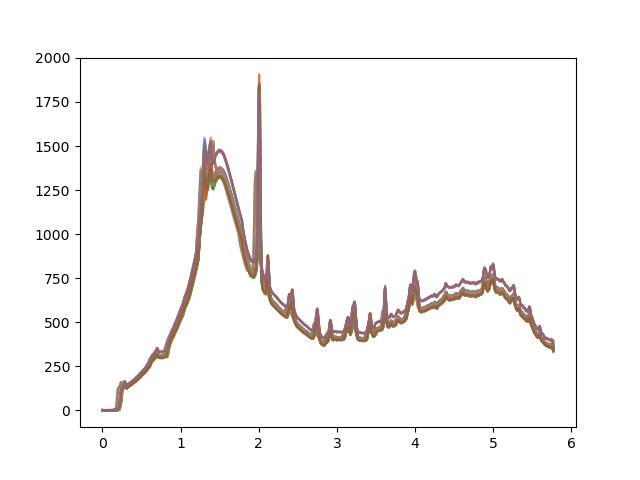

In [48]:
plt.figure()
plt.plot(radial_out, profiles.T, alpha=0.5)
plt.show()